# **1. Load and Understand Dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np

file_path = "/content/drive/MyDrive/Healthcare_Analytics/diabetic_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 101766
Columns: 50


# **CLEANING DATASET**

In [4]:
clean_df = df.copy()

print("Cleaning copy created!")
print(clean_df.shape)

Cleaning copy created!
(101766, 50)


In [5]:
missing_report = pd.DataFrame({
    "Question_Mark": clean_df.isin(["?"]).sum(),
    "NaN": clean_df.isnull().sum()
})

missing_report = missing_report[
    (missing_report["Question_Mark"] > 0) |
    (missing_report["NaN"] > 0)
]

missing_report

,Question_Mark,NaN
race,2273,0
weight,98569,0
payer_code,40256,0
medical_specialty,49949,0
diag_1,21,0
diag_2,358,0
diag_3,1423,0
max_glu_serum,0,96420
A1Cresult,0,84748


In [6]:
clean_df = clean_df.replace("?", np.nan)

print("Unknown values converted to NaN.")

Unknown values converted to NaN.


In [7]:
missing_percent = clean_df.isnull().mean() * 100

missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

missing_percent

,0
weight,96.858479
max_glu_serum,94.746772
A1Cresult,83.277322
medical_specialty,49.082208
payer_code,39.557416
race,2.233555
diag_3,1.398306
diag_2,0.351787
diag_1,0.020636


In [8]:
high_missing_cols = [
    "weight",
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
    "payer_code"
]

clean_df = clean_df.drop(columns=high_missing_cols)

print("Removed columns:", high_missing_cols)
print("New shape:", clean_df.shape)

Removed columns: ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code']
New shape: (101766, 45)


In [9]:
categorical_missing_cols = [
    "race",
    "diag_1",
    "diag_2",
    "diag_3"
]

clean_df[categorical_missing_cols] = clean_df[categorical_missing_cols].fillna("Unknown")

print("Remaining missing values:")
print(clean_df.isnull().sum().sum())

Remaining missing values:
0


In [10]:
duplicate_count = clean_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [11]:
clean_df["readmitted"].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [12]:
clean_df["readmitted_30"] = clean_df["readmitted"].map({
    "<30": 1,
    ">30": 0,
    "NO": 0
})

print(clean_df["readmitted_30"].value_counts())

readmitted_30
0    90409
1    11357
Name: count, dtype: int64


In [13]:
print("Identifier columns:")
print(clean_df[["encounter_id", "patient_nbr"]].head())

Identifier columns:
   encounter_id  patient_nbr
0       2278392      8222157
1        149190     55629189
2         64410     86047875
3        500364     82442376
4         16680     42519267


In [14]:
print("Final cleaned dataset shape:", clean_df.shape)

print("\nRemaining missing values:")
print(clean_df.isnull().sum().sum())

print("\nDuplicate rows:")
print(clean_df.duplicated().sum())

print("\nTarget distribution:")
print(clean_df["readmitted_30"].value_counts())

Final cleaned dataset shape: (101766, 46)

Remaining missing values:
0

Duplicate rows:
0

Target distribution:
readmitted_30
0    90409
1    11357
Name: count, dtype: int64


In [15]:
output_path = "/content/drive/MyDrive/Healthcare_Analytics/cleaned_diabetic_data.csv"

clean_df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")
print(output_path)


Cleaned dataset saved successfully!
/content/drive/MyDrive/Healthcare_Analytics/cleaned_diabetic_data.csv


# **WEEK-3 EDA and Visualizations**

In [16]:
print("Dataset Shape:", clean_df.shape)

print("\nData Types:")
print(clean_df.dtypes)

print("\nBasic Statistics:")
print(clean_df.describe())

Dataset Shape: (101766, 46)

Data Types:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide                   object
glyburide                   object
tolbutamide   

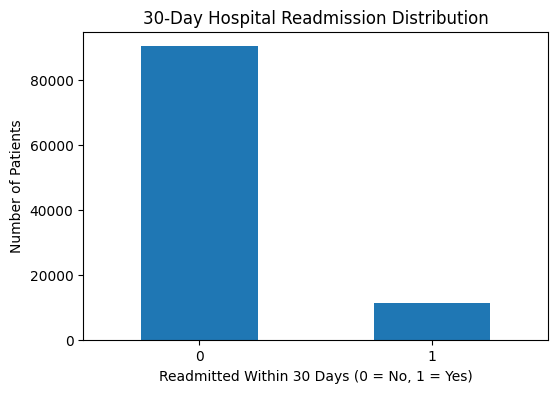

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

clean_df["readmitted_30"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("30-Day Hospital Readmission Distribution")
plt.xlabel("Readmitted Within 30 Days (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.show()

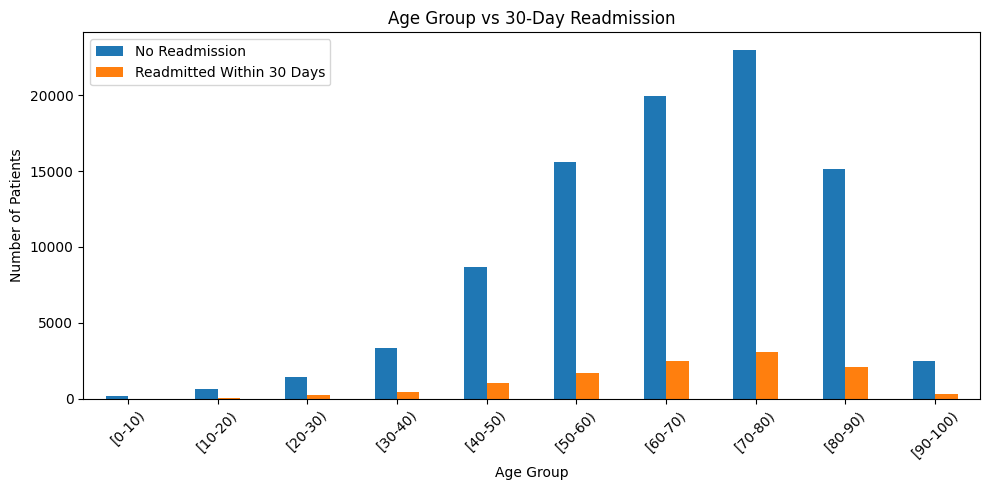

In [18]:
import matplotlib.pyplot as plt

age_readmission = pd.crosstab(
    clean_df["age"],
    clean_df["readmitted_30"]
)

age_readmission = age_readmission.reindex([
    "[0-10)", "[10-20)", "[20-30)", "[30-40)",
    "[40-50)", "[50-60)", "[60-70)", "[70-80)",
    "[80-90)", "[90-100)"
])

age_readmission.plot(kind="bar", figsize=(10,5))

plt.title("Age Group vs 30-Day Readmission")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.legend(["No Readmission", "Readmitted Within 30 Days"])
plt.tight_layout()
plt.show()

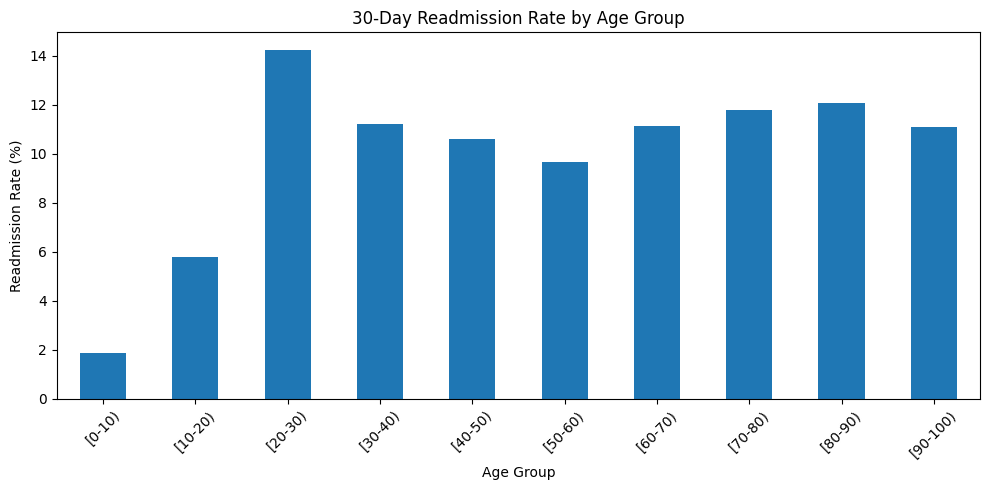

Age-wise 30-day readmission rate:
age
[0-10)       1.86
[10-20)      5.79
[20-30)     14.24
[30-40)     11.23
[40-50)     10.60
[50-60)      9.67
[60-70)     11.13
[70-80)     11.77
[80-90)     12.08
[90-100)    11.10
Name: readmitted_30, dtype: float64


In [19]:
age_rate = clean_df.groupby("age")["readmitted_30"].mean() * 100

age_rate = age_rate.reindex([
    "[0-10)", "[10-20)", "[20-30)", "[30-40)",
    "[40-50)", "[50-60)", "[60-70)", "[70-80)",
    "[80-90)", "[90-100)"
])

plt.figure(figsize=(10, 5))

age_rate.plot(kind="bar")

plt.title("30-Day Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Age-wise 30-day readmission rate:")
print(age_rate.round(2))

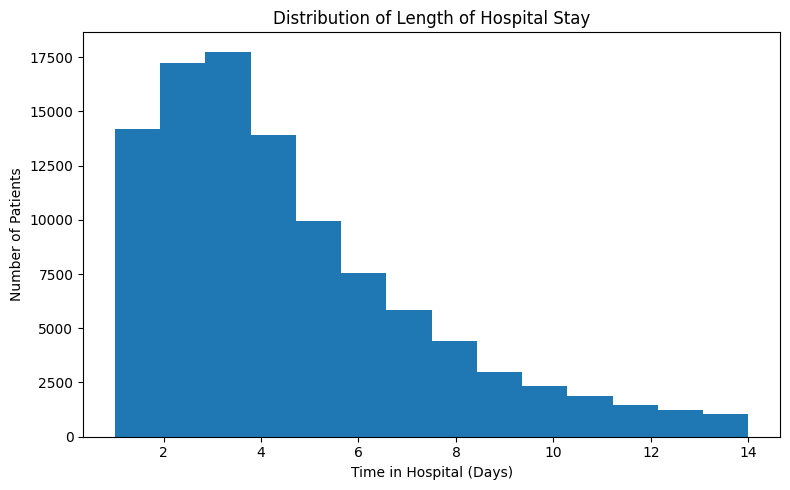

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(
    clean_df["time_in_hospital"],
    bins=14
)

plt.title("Distribution of Length of Hospital Stay")
plt.xlabel("Time in Hospital (Days)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()


<Figure size 800x500 with 0 Axes>

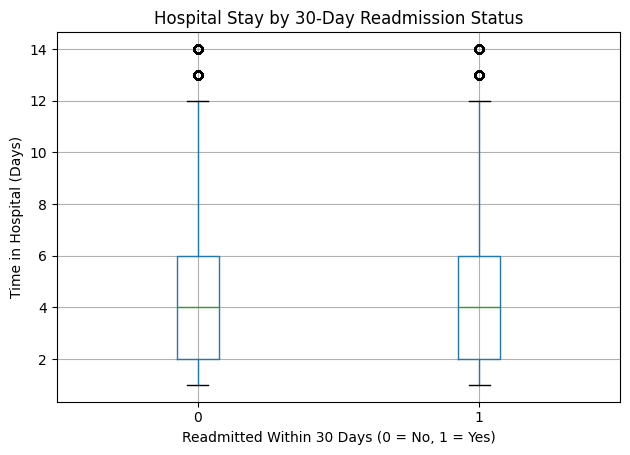

In [21]:
plt.figure(figsize=(8, 5))

clean_df.boxplot(
    column="time_in_hospital",
    by="readmitted_30"
)

plt.title("Hospital Stay by 30-Day Readmission Status")
plt.suptitle("")
plt.xlabel("Readmitted Within 30 Days (0 = No, 1 = Yes)")
plt.ylabel("Time in Hospital (Days)")

plt.tight_layout()
plt.show()

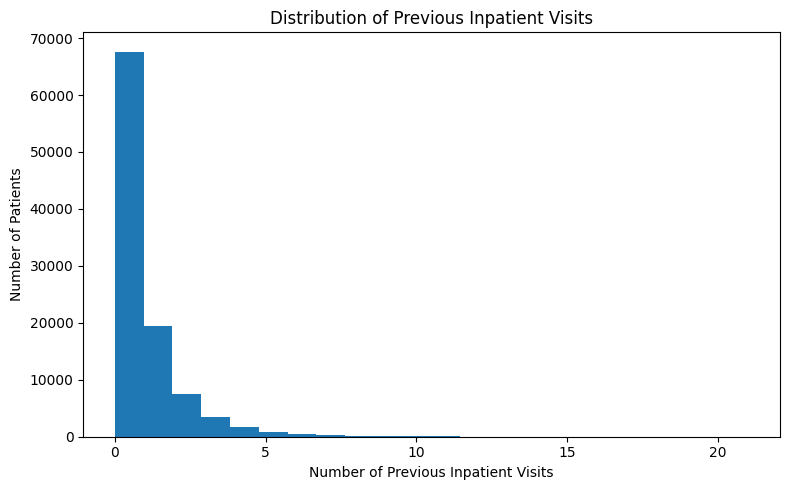

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(
    clean_df["number_inpatient"],
    bins=22
)

plt.title("Distribution of Previous Inpatient Visits")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [23]:
inpatient_rate = clean_df.groupby("number_inpatient")["readmitted_30"].mean() * 100

print("30-day readmission rate by previous inpatient visits:")
print(inpatient_rate.round(2))

30-day readmission rate by previous inpatient visits:
number_inpatient
0       8.44
1      12.92
2      17.43
3      20.29
4      23.61
5      31.40
6      34.58
7      35.45
8      44.37
9      42.34
10     42.62
11     67.35
12     50.00
13     50.00
14     40.00
15    100.00
16     33.33
17    100.00
18      0.00
19     50.00
21    100.00
Name: readmitted_30, dtype: float64


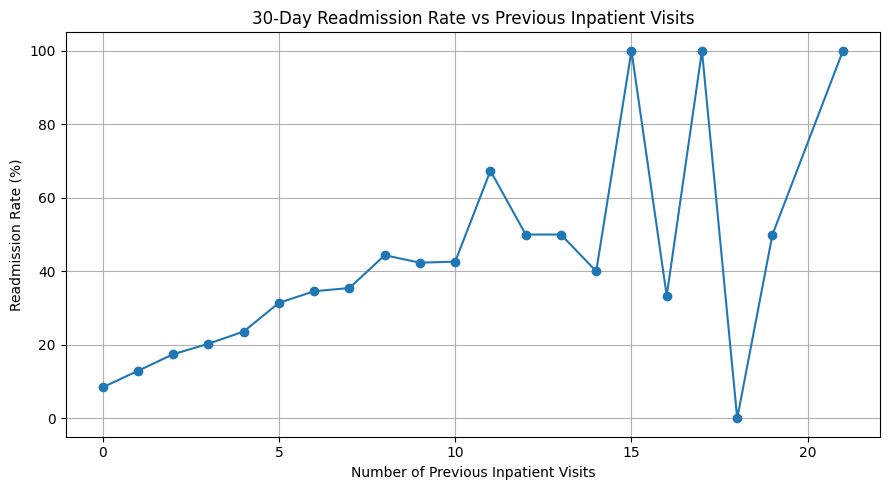

In [24]:
plt.figure(figsize=(9, 5))

inpatient_rate.plot(kind="line", marker="o")

plt.title("30-Day Readmission Rate vs Previous Inpatient Visits")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("Readmission Rate (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

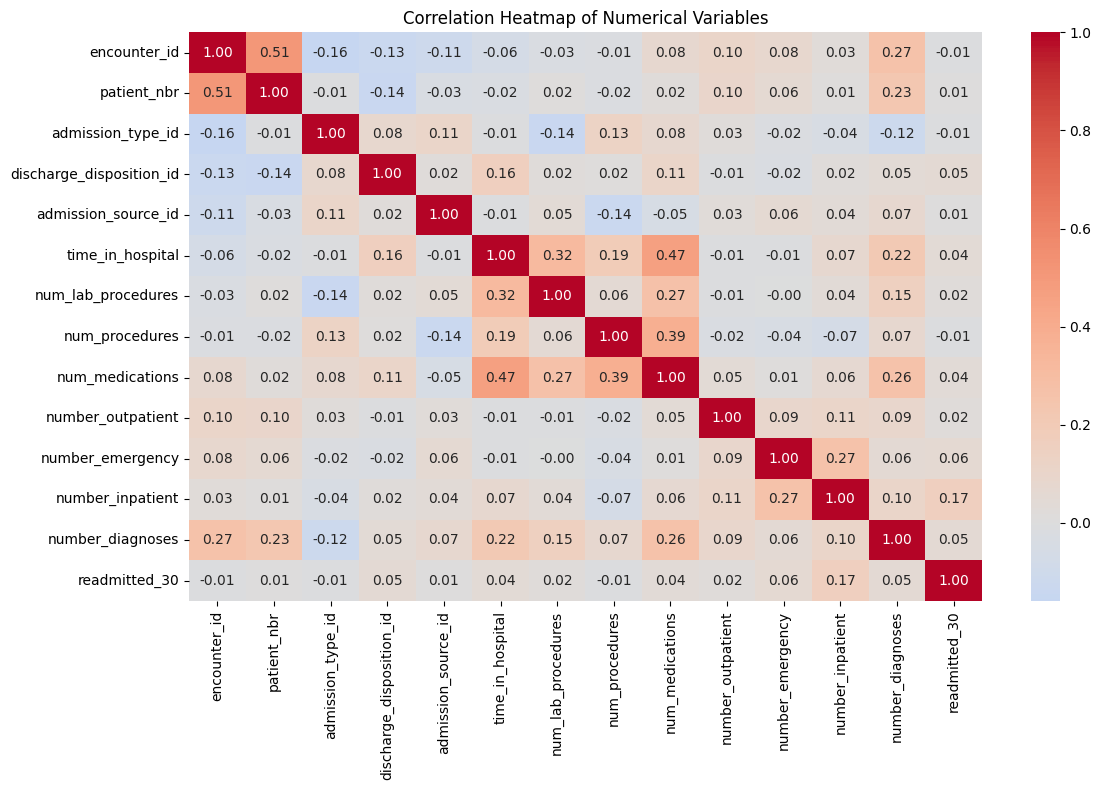

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = clean_df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

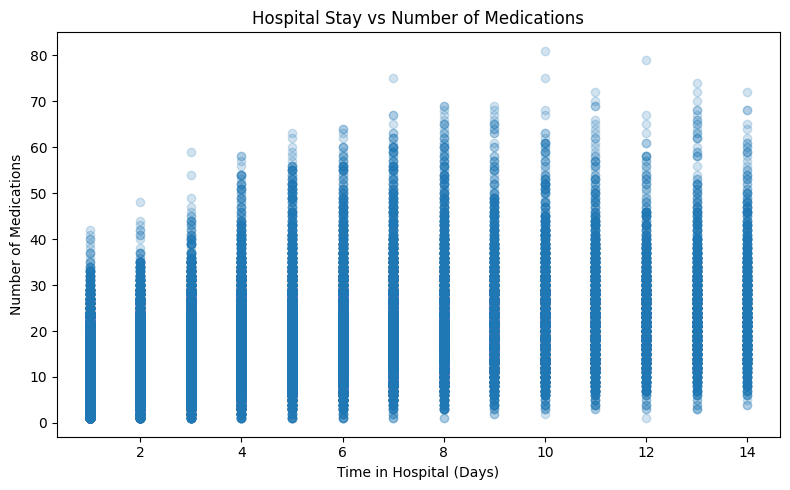

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(
    clean_df["time_in_hospital"],
    clean_df["num_medications"],
    alpha=0.2
)

plt.title("Hospital Stay vs Number of Medications")
plt.xlabel("Time in Hospital (Days)")
plt.ylabel("Number of Medications")

plt.tight_layout()
plt.show()

Gender-wise 30-day readmission rate:
gender
Female             11.25
Male               11.06
Unknown/Invalid     0.00
Name: readmitted_30, dtype: float64


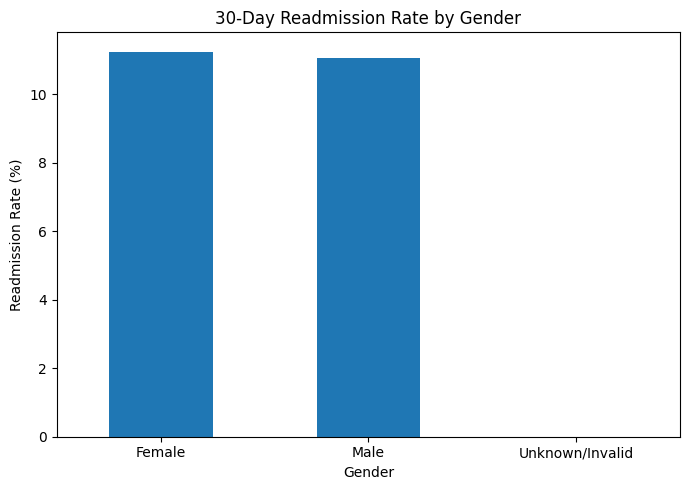

In [27]:
gender_rate = clean_df.groupby("gender")["readmitted_30"].mean() * 100

print("Gender-wise 30-day readmission rate:")
print(gender_rate.round(2))

plt.figure(figsize=(7, 5))

gender_rate.plot(kind="bar")

plt.title("30-Day Readmission Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [28]:
print("Gender-wise 30-day readmission rate:")
print(gender_rate.round(2))

Gender-wise 30-day readmission rate:
gender
Female             11.25
Male               11.06
Unknown/Invalid     0.00
Name: readmitted_30, dtype: float64
